In [1]:
import h5py
from pathlib import Path
import time
import os
from PIL import Image
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
from ultralytics import YOLO 


In [ ]:

f = h5py.File('train_digitStruct.mat', 'r')
ref =  f['digitStruct']['bbox']

name_list = (list(f['digitStruct']['name']))
print(name_list[1:5])

[array([<HDF5 object reference>], dtype=object), array([<HDF5 object reference>], dtype=object), array([<HDF5 object reference>], dtype=object), array([<HDF5 object reference>], dtype=object)]


In [ ]:
image_path = Path('data/images/train')

for f in (image_path).iterdir():
        if f.stem.isdigit() and int(f.stem) > 3600:
            f.unlink()

#### Обработка формата .mat

In [ ]:
MAT_PATH = "train_digitStruct.mat"      # путь к файлу
IMAGES_DIR = "data/images/train"             # папка где лежат  фото (1.png, 2.png, ...)
LABELS_DIR = "data/labels/train"             # куда сохранять .txt
 
os.makedirs(LABELS_DIR, exist_ok=True)
 
f = h5py.File(MAT_PATH, "r")
names = f["digitStruct"]["name"]
bboxes = f["digitStruct"]["bbox"]
 
 
def get_name(i):
    ref = names[i][0]
    return "".join(chr(c[0]) for c in f[ref][()])
 
 
def get_attr(box_group, key):
    attr = box_group[key]
    if len(attr) > 1:
        return [f[attr[j][0]][()][0][0] for j in range(len(attr))]
    else:
        return [attr[()][0][0]]
 
 
for i in range(names.shape[0]):
    filename = get_name(i)                      # например "1.png"
    box_group = f[bboxes[i][0]]
 
    labels = get_attr(box_group, "label")
    tops    = get_attr(box_group, "top")
    lefts   = get_attr(box_group, "left")
    heights = get_attr(box_group, "height")
    widths  = get_attr(box_group, "width")
 
    img_path = os.path.join(IMAGES_DIR, filename)
    if not os.path.exists(img_path):
        continue  # пропускаем, если картинки нет
 
    img_w, img_h = Image.open(img_path).size
 
    lines = []
    for label, top, left, h, w in zip(labels, tops, lefts, heights, widths):
        class_id = 0 if int(label) == 10 else int(label)  # SVHN: 10 -> 0
 
        x_center = (left + w / 2) / img_w
        y_center = (top + h / 2) / img_h
        w_norm = w / img_w
        h_norm = h / img_h
 
        lines.append(f"{class_id} {x_center:.6f} {y_center:.6f} {w_norm:.6f} {h_norm:.6f}")
 
    txt_name = os.path.splitext(filename)[0] + ".txt"
    with open(os.path.join(LABELS_DIR, txt_name), "w") as out:
        out.write("\n".join(lines))
 
print(" Аннотации сохранены в", LABELS_DIR)

 Аннотации сохранены в data/labels/train


In [32]:
import shutil

image_path_train = Path('data/images/train')
image_path_val = Path('data/images/val')
image_path_test = Path('data/images/test')

label_path_train = Path('data/labels/train')
label_path_val = Path('data/labels/val')
label_path_test = Path('data/labels/test')

for f in ((image_path_train).iterdir()):
        if f.stem.isdigit() and int(f.stem) < 101:
            shutil.move(f,image_path_test)
        if f.stem.isdigit() and int(f.stem) > 100 and int(f.stem)<601:
            shutil.move(f,image_path_val)

for f in ((label_path_train).iterdir()):
        if f.stem.isdigit() and int(f.stem) < 101:
            shutil.move(f,label_path_test)
        if f.stem.isdigit() and int(f.stem) > 100 and int(f.stem)<601:
            shutil.move(f,label_path_val)

In [ ]:
model = YOLO('models/yolo12n.pt')

### Обучение модели на тренировочных данных 

In [ ]:
start_time = time.time()

result = model.train(
    data='digith_detection.yaml',
    epochs = 10 ,
    batch=16,        #  на CPU большой batch не даёт ускорения, только грузит память
    imgsz=320,       # размер входного изображения 
    workers=4,        # параллельная загрузка данных (под кол-во ядер CPU)
    name='yolo12n_train', # 
    patience=5,        # ранняя остановка, если нет улучшения N эпох
    plots=True,          # сохраняет графики (confusion matrix, PR-curve, и т.д.) в папку runs
    save_period=5,       # сохранять чекпойнт каждые 5 эпох
    verbose=True,        # подробный вывод
    project='artifacts',  # куда сохранять результаты
)

end_time = time.time()

output_dir = 'artifacts'

model.save(os.path.join(output_dir, 'hous_number_detect_yolo12n.pt'))

print(f'model saved, time = {end_time-start_time}')


Ultralytics 8.4.75  Python-3.13.9 torch-2.12.1+cpu CPU (AMD Ryzen 7 8845HS w/ Radeon 780M Graphics)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=digith_detection.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=320, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=models/yolo12n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo12n_train-4, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap

<img src = "runs/detect/artifacts/yolo12n_train-4/labels.jpg" width = '400' height = '400'>

Не считая 1 и 2 классы сбалансированны более менее равномерно , на каждый приходится около 500 примеров 

In [10]:
mode_l = YOLO('runs/detect/artifacts/yolo12n_train-4/weights/last.pt')

result_val = mode_l.val(
    data = 'digith_detection.yaml',
    imgsz = 320,
    batch=16,
    split = 'val',
    conf=0.001,            # низкий порог confidence — чтобы AP считался по всей PR-кривой честно
    plots=True,            
    save_json=True,  
)

Ultralytics 8.4.75  Python-3.13.9 torch-2.12.1+cpu CPU (AMD Ryzen 7 8845HS w/ Radeon 780M Graphics)
YOLOv12n summary (fused): 159 layers, 2,558,678 parameters, 0 gradients
val: Fast image access  (ping: 0.40.1 ms, read: 12.16.3 MB/s, size: 5.4 KB)
val: Scanning C:\Users\Carolina\Desktop\CV_ete\YOLA_beginner2026\continued_after_pause\data\labels\val.cache... 500 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 500/500 80.7Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 32/32 5.3it/s 6.0s0.2s
                   all        500       1080      0.846      0.795      0.866      0.435
                     0         66         71      0.874      0.901      0.918      0.469
                     1        204        236      0.852      0.779      0.861      0.359
                     2        129        136      0.859      0.868      0.897      0.464
                     3        117        130      0.866      0.715      0.

Как можно заключить из полученных значений на валидации для 500 изображений из валидационного датасета модель разметила 1080 bounding boxes(это число предсказаний при той рабочей точке (confidence threshold), при которой считались P/R)

Общая полнота предсказаний  recall = 0.795 (заметим, около 20% объектов модель просто не обнаружила), 

Общая точность precision 0.846 -- (точки максимума F1 на PR-кривой).

 Метрики   mAP50 — mean Average Precision при IoU = 0.5 (для каждого класса считается AP( (площадь под Precision-Recall кривой), при фиксированном пороге IoU = 0.5 ) то есть рассматриваемый bbox TP если пересечение с истинным 50%)=0,866  mAP50-95 (усредненные значения для перечечения от 50 до 95%) =0,435  , различие между этимо параметрами в 43%  можно интерпретировать как то, что модель не плохо предсказывает примерное расположение объектов , но точная логика даётся существенно хуже чем примерная  .

Данные оценки были получены при достаточно небольшом обучаюзем датасете 3000 экземпляров и с самой мини версией YOLO "yolo12n" поэтому при наличии необходимых пощностей можно достаточно просто улучшить итоговые результаты и точность предсказаний .

<img src = "runs\detect\artifacts\yolo12n_train-4\confusion_matrix_normalized.png" width = '450' height = '400'> 

на данном графике можно проследить какие классы модель путает чаще всего , например задний фон с цыфрой один имеет вообще знасение 32 %

In [12]:
from pathlib import Path
mode_l = YOLO('runs/detect/artifacts/yolo12n_train-4/weights/last.pt')

result_test = mode_l.val(data='digith_detection.yaml', split='test', imgsz=320)

test_images_dir = Path('data/images/test')
image_files = sorted(test_images_dir.glob('*.png'))[10:20]  # первые 10 файлов

results = mode_l.predict(source=image_files, conf=0.25, save=False)
import matplotlib.pyplot as plt


Ultralytics 8.4.75  Python-3.13.9 torch-2.12.1+cpu CPU (AMD Ryzen 7 8845HS w/ Radeon 780M Graphics)
YOLOv12n summary (fused): 159 layers, 2,558,678 parameters, 0 gradients
val: Fast image access  (ping: 0.00.0 ms, read: 297.2334.2 MB/s, size: 19.9 KB)
val: Scanning C:\Users\Carolina\Desktop\CV_ete\YOLA_beginner2026\continued_after_pause\data\labels\test.cache... 100 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 100/100 18.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 7/7 9.1it/s 0.8s0.1s
                   all        100        220      0.873      0.853      0.909      0.494
                     0         10         10      0.829        0.8      0.888      0.515
                     1         39         43      0.816       0.86      0.912      0.401
                     2         32         36      0.888       0.88      0.883      0.432
                     3         30         32      0.781      0.844     

### Визуализация отработки модели на тесте 

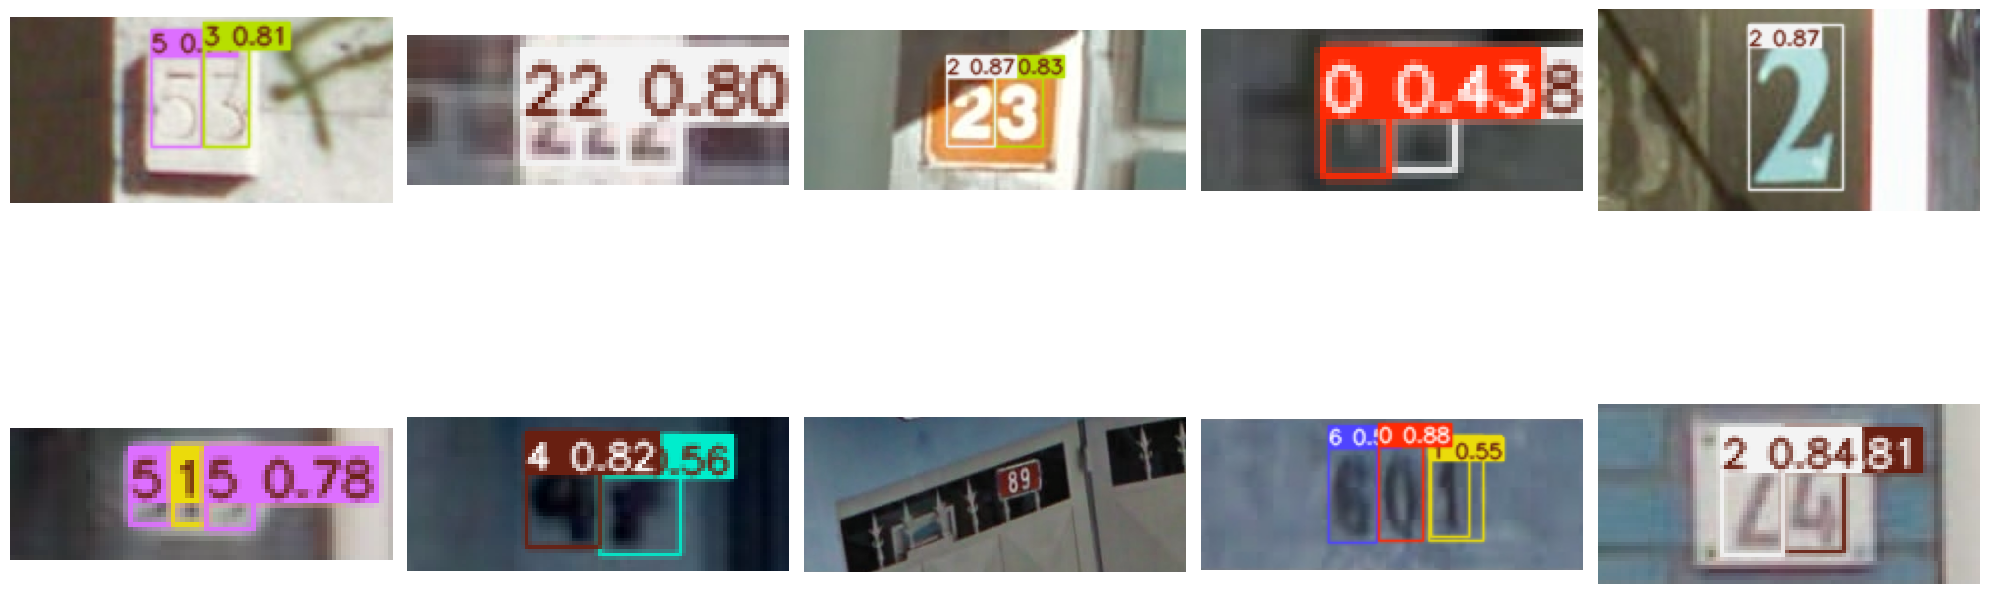

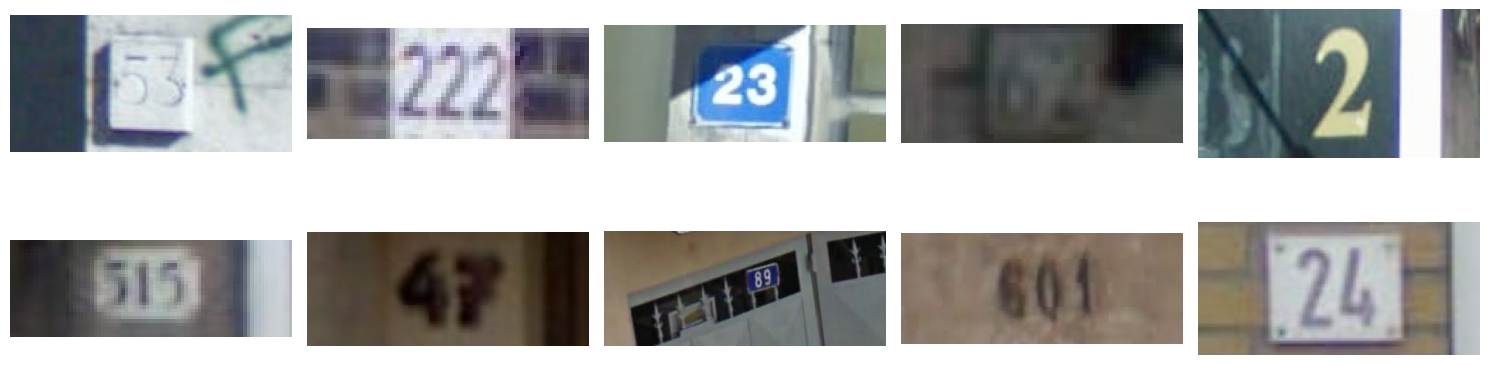

In [31]:
%matplotlib inline
fig, axes = plt.subplots(2, 5, figsize=(20, 10))

for ax, result in zip(axes.flatten(), results):
    img = result.plot(line_width=1,  labels=True, conf=True)        # картинка с нарисованными bbox и метками
    ax.imshow(img)
    ax.axis('off')

plt.tight_layout()


fig, axes = plt.subplots(2, 5, figsize=(15, 5))

test_im_path = Path('data/images/test')
images = sorted(test_im_path.iterdir())[10:20]
for ax, img in zip(axes.flatten(), images):
    image = Image.open(img)
    ax.imshow(image)
    ax.axis('off')

plt.tight_layout()